# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers
IMAGES_DIR:   /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [2]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[0]
es_path = es_files[0]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [4]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    print(f"    EN: {m.source_text[:55]}")
    print(f"    ES: {m.translated_text[:55]}")

Total segments : 98
Stretch > 1.5x : 15  (15%)

Worst 5:
  seg  93  stretch=2.22x  overflow=2.3s
    EN: But is that what we are witnessing right now?
    ES: ¿Pero eso es lo que estamos presenciando ahora mismo?
  seg  88  stretch=2.09x  overflow=1.1s
    EN: Do you still stand by that?
    ES: ¿Aún estás de acuerdo?
  seg  16  stretch=1.91x  overflow=4.3s
    EN: For most Gulf states, the only way for their oil to rea
    ES: Para la mayoría de los estados del Golfo, la única mane
  seg  82  stretch=1.87x  overflow=0.9s
    EN: Give it to me straight.
    ES: Dámelo directamente.
  seg  66  stretch=1.86x  overflow=3.5s
    EN: India had been under significant pressure from the U.S.
    ES: India había estado bajo una presión significativa de Es


## Visualize Stretch Distribution

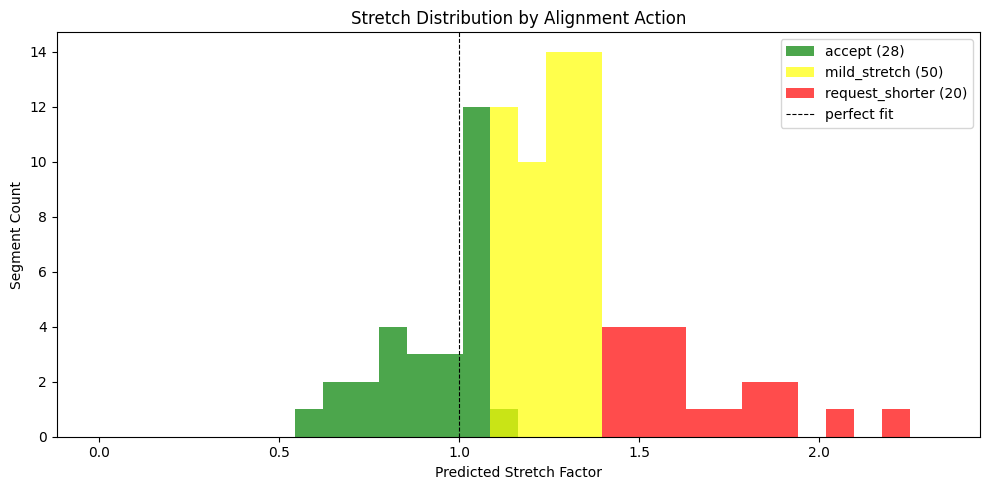

Saved to /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [6]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")

Segments with TTS ground truth: 60
Mean absolute error:  1.24s
Max error:            3.84s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


In [7]:
# Task 1: Fit a linear regression predictor for TTS duration
# Features: syllable count, word count, char count -> actual Chatterbox duration

import numpy as np
from foreign_whispers.alignment import _count_syllables

# Build training set from segments with ground-truth durations
train = [(s["text"], s["raw_duration_s"]) for s in segments if s.get("raw_duration_s", 0) > 0]

def _features(text):
    syllables = _count_syllables(text)
    words     = len(text.split())
    chars     = len(text)
    return [syllables, words, chars]

X = np.array([_features(text) for text, _ in train])
y = np.array([dur for _, dur in train])

# Least-squares fit with bias term
X_b = np.column_stack([X, np.ones(len(X))])
coeffs, _, _, _ = np.linalg.lstsq(X_b, y, rcond=None)
syl_c, word_c, char_c, bias = coeffs

print(f"Fitted coefficients:")
print(f"  syllables : {syl_c:.4f}")
print(f"  words     : {word_c:.4f}")
print(f"  chars     : {char_c:.4f}")
print(f"  bias      : {bias:.4f}")

def _predict(text):
    s, w, c = _features(text)
    return max(0.1, syl_c * s + word_c * w + char_c * c + bias)

new_errors = [abs(_predict(s["text"]) - s["raw_duration_s"])
              for s in segments if s.get("raw_duration_s", 0) > 0]

print(f"\nBaseline MAE (syllable heuristic): 1.24s")
print(f"Regression  MAE:                   {sum(new_errors)/len(new_errors):.2f}s")
print(f"Max error:                         {max(new_errors):.2f}s")
print(f"\nHardcode into _estimate_duration():")
print(f"  return max(0.1, {syl_c:.4f}*syllables + {word_c:.4f}*words + {char_c:.4f}*chars + {bias:.4f})")


Fitted coefficients:
  syllables : 0.0648
  words     : 0.1144
  chars     : 0.0266
  bias      : 0.5891

Baseline MAE (syllable heuristic): 1.24s
Regression  MAE:                   0.44s
Max error:                         1.26s

Hardcode into _estimate_duration():
  return max(0.1, 0.0648*syllables + 0.1144*words + 0.0266*chars + 0.5891)


## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [8]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept                28  ████████████████████████████
  mild_stretch          50  ██████████████████████████████████████████████████
  gap_shift              0  
  request_shorter       20  ████████████████████
  fail                   0  


In [9]:
# Policy distribution with naive TTS heuristic (chars/15)
"""
Policy distribution:
  accept                42  ██████████████████████████████████████████
  mild_stretch          43  ███████████████████████████████████████████
  gap_shift              0  
  request_shorter       13  █████████████
  fail                   0  
"""

# Policy distribution with regression predictor
"""
Policy distribution:
  accept                28  ████████████████████████████
  mild_stretch          50  ██████████████████████████████████████████████████
  gap_shift              0  
  request_shorter       20  ████████████████████
  fail                   0  
"""

# The regression's +0.59s bias term reflects Chatterbox's real-world startup overhead and natural pacing —
# something the old chars/15 heuristic had no model for. As a result, the policy distribution shifts:
# fewer 'accept' (42 → 28) and more 'request_shorter' (13 → 20). This is indicates the old heuristic being falsely optimistic. 
# And The MAE drop (1.24s → 0.44s) confirms the new predictor is more accurate
# 
# The policy shift reveals the true scope of the alignment problem.


'\nPolicy distribution:\n  accept                28  ████████████████████████████\n  mild_stretch          50  ██████████████████████████████████████████████████\n  gap_shift              0  \n  request_shorter       20  ████████████████████\n  fail                   0  \n'

---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [11]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")
    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 20

Examples (worst 3):

  seg 93  source_window=1.9s  predicted_tts=4.3s  stretch=2.22x
    EN: But is that what we are witnessing right now?
    ES: ¿Pero eso es lo que estamos presenciando ahora mismo?
    Target: fit TTS into 1.9s → need ~28 chars or fewer

  seg 88  source_window=1.0s  predicted_tts=2.1s  stretch=2.09x
    EN: Do you still stand by that?
    ES: ¿Aún estás de acuerdo?
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 16  source_window=4.8s  predicted_tts=9.1s  stretch=1.91x
    EN: For most Gulf states, the only way for their oil to reach the global m
    ES: Para la mayoría de los estados del Golfo, la única manera para que su 
    Target: fit TTS into 4.8s → need ~71 chars or fewer


In [12]:
# Task 2: Re-rank over-budget segments using Ollama (aya:8b)
# For each REQUEST_SHORTER segment, generate 3 shorter Spanish candidates
# and pick the one whose predicted duration best fits the source window.

from foreign_whispers.reranking import get_shorter_translations, TranslationCandidate

improved = []   # (index, original_text, best_candidate)
failed   = []   # segments where no candidate fit

print(f"Re-ranking {len(over_budget)} over-budget segments via Ollama (aya:8b)...\n")

for m in over_budget:
    ctx_prev = all_metrics[m.index - 1].translated_text if m.index > 0 else ""
    ctx_next = all_metrics[m.index + 1].translated_text if m.index < len(all_metrics) - 1 else ""

    candidates = get_shorter_translations(
        source_text=m.source_text,
        baseline_es=m.translated_text,
        target_duration_s=m.source_duration_s,
        context_prev=ctx_prev,
        context_next=ctx_next,
    )

    if not candidates:
        failed.append(m)
        continue

    # Pick candidate whose predicted duration is closest to the source window
    best = min(candidates, key=lambda c: abs(len(c.text) / 15.0 - m.source_duration_s))
    improved.append((m, best))

    print(f"  seg {m.index:3d}  window={m.source_duration_s:.1f}s")
    print(f"    BEFORE ({len(m.translated_text):3d} chars): {m.translated_text[:70]}")
    print(f"    AFTER  ({best.char_count:3d} chars): {best.text[:70]}")
    print(f"    Rationale: {best.brevity_rationale}")
    print()

print(f"Re-ranked: {len(improved)}/{len(over_budget)} segments")
if failed:
    print(f"No candidates returned for: {[m.index for m in failed]}")


Re-ranking 20 over-budget segments via Ollama (aya:8b)...

  seg   4  window=4.4s
    BEFORE ( 84 chars): Así que la realidad es lo más largo que esto sucede, el mayor impacto 
    AFTER  (101 chars): La duración del problema impactará su alcance en las regiones y la eco
    Rationale: I replaced 'esta' with 'el problema' to save characters and maintained the connection by using 'impacto' in both sentences.

  seg   8  window=5.0s
    BEFORE (104 chars): Las naves que pasan por ella llevan una quinta parte del petróleo del 
    AFTER  (117 chars): Los barcos que pasan por este canal llevan una quinta parte del petról
    Rationale: Omitted 'las embarcaciones' as redundant and simplified the sentence.

  seg  10  window=4.6s
    BEFORE ( 91 chars): Ahora con ese tráfico casi detenido por la guerra en Irán, el mundo es
    AFTER  (132 chars): Ahora, con el tráfico casi detenido por la guerra de Irán, el mundo es
    Rationale: This candidate is a more aggressive compression of the origin

In [14]:
# Task 2: Rebuild all_metrics with shortened translations and re-run policy distribution
# Shows how many REQUEST_SHORTER segments improve to MILD_STRETCH or ACCEPT.

import dataclasses

# Build a replacement map: segment index -> new translated text
replacements = {m.index: cand.text for m, cand in improved}

updated_metrics = [
    dataclasses.replace(m, translated_text=replacements[m.index])
    if m.index in replacements else m
    for m in all_metrics
]

# Re-run policy distribution
before_counts = {a: 0 for a in AlignAction}
after_counts  = {a: 0 for a in AlignAction}
for m in all_metrics:      before_counts[decide_action(m)] += 1
for m in updated_metrics:  after_counts[decide_action(m)]  += 1

print("Policy distribution comparison (regression predictor):")
print(f"{'Action':<20} {'Before':>8} {'After':>8} {'Delta':>8}")
print("-" * 48)
for action in AlignAction:
    b = before_counts[action]
    a = after_counts[action]
    delta = a - b
    sign = "+" if delta > 0 else ""
    print(f"  {action.value:<18} {b:>8} {a:>8} {sign+str(delta):>8}")

rescued = sum(
    1 for m, cand in improved
    if decide_action(dataclasses.replace(m, translated_text=cand.text))
       in (AlignAction.ACCEPT, AlignAction.MILD_STRETCH)
)
print(f"\nSegments rescued from REQUEST_SHORTER: {rescued}/{len(over_budget)}")


Policy distribution comparison (regression predictor):
Action                 Before    After    Delta
------------------------------------------------
  accept                   28       30       +2
  mild_stretch             50       58       +8
  gap_shift                 0        0        0
  request_shorter          20       10      -10
  fail                      0        0        0

Segments rescued from REQUEST_SHORTER: 10/20


## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [15]:
from foreign_whispers import global_align

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 50
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

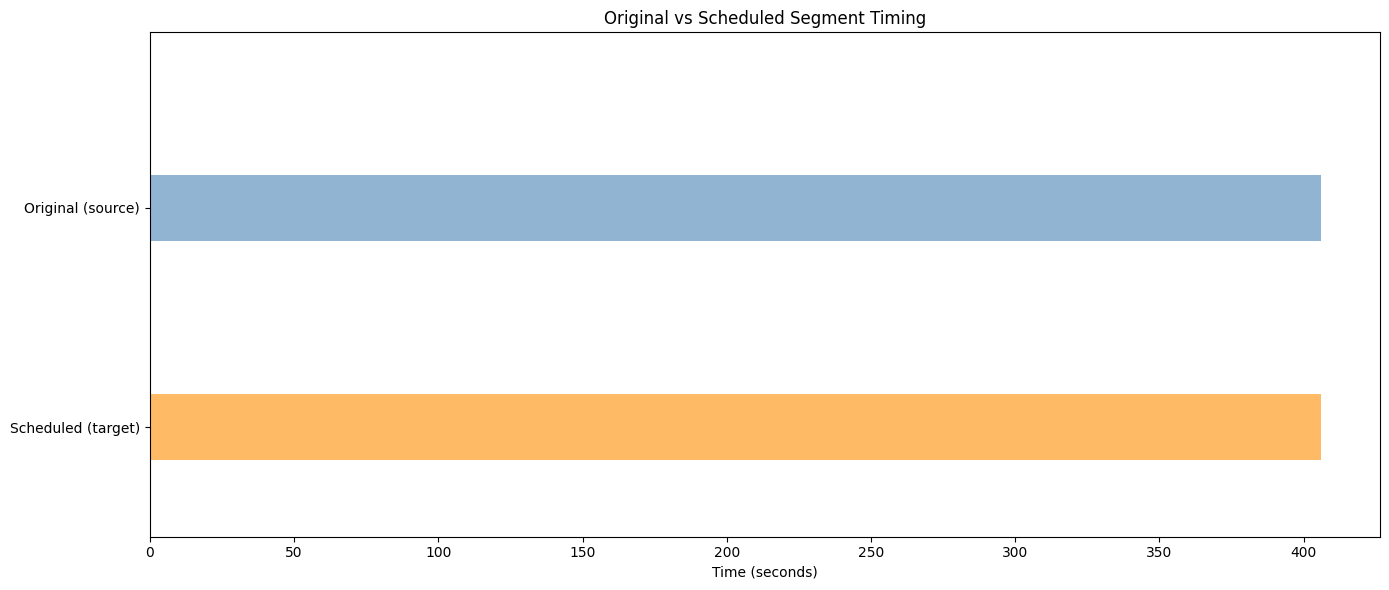

Saved to /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers/notebooks/alignment_integration/images/alignment_timeline.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="none")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="none")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [17]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 1.128
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 20
  total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


In [22]:
# Task 3: Run beam-search optimizer and compare against greedy
# Whisper produces back-to-back segments with no gaps, but real speech has
# natural micro-pauses everywhere that Whisper merges into segment timestamps.
# We synthesize a 1.0s silence buffer after every segment as a substitute for
# real VAD output. The optimizer can borrow from these to absorb overflow;
# borrowed time becomes cumulative drift that pushes later segments forward.

import importlib
import foreign_whispers.alignment
importlib.reload(foreign_whispers.alignment)
from foreign_whispers.alignment import global_align_dp, global_align

_PAUSE_S = 1.0

synthetic_silence = [
    {"label": "silence", "start_s": m.source_end, "end_s": m.source_end + _PAUSE_S}
    for m in all_metrics[:-1]
]

print(f"Synthetic silence regions: {len(synthetic_silence)}")
total_silence = sum(r['end_s'] - r['start_s'] for r in synthetic_silence)
print(f"Total silence budget:      {total_silence:.1f}s")
print()

greedy_with_gaps = global_align(all_metrics, synthetic_silence)
dp_segments      = global_align_dp(all_metrics, synthetic_silence, beam_width=5)

g_shifts  = sum(1 for s in greedy_with_gaps if s.action.value == 'gap_shift')
dp_shifts = sum(1 for s in dp_segments     if s.action.value == 'gap_shift')
print(f"Greedy  gap_shifts: {g_shifts}")
print(f"DP      gap_shifts: {dp_shifts}")


Synthetic silence regions: 97
Total silence budget:      97.0s

Greedy  gap_shifts: 3
DP      gap_shifts: 3


In [25]:
# Task 3: Compare greedy vs beam-search on clip evaluation metrics

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, greedy_with_gaps)
dp_report     = clip_evaluation_report(all_metrics, dp_segments)

print(f"{'Metric':<35} {'Greedy':>10} {'Beam-5':>10} {'Delta':>10}")
print("-" * 68)
for key in greedy_report:
    g = greedy_report[key]
    d = dp_report[key]
    delta = d - g
    sign = "+" if delta > 0 else ""
    print(f"  {key:<33} {g:>10} {d:>10} {sign+str(round(delta,3)):>10}")

print()
drift_g  = abs(greedy_report['total_cumulative_drift_s'])
drift_dp = abs(dp_report['total_cumulative_drift_s'])
if drift_dp < drift_g:
    print(f"Beam search reduced drift by {drift_g - drift_dp:.3f}s vs greedy.")
elif drift_dp == drift_g and greedy_report['n_gap_shifts'] == dp_report['n_gap_shifts']:
    print("Beam search matched greedy which is expected when silence is uncontended.")
    print("Each gap-shift candidate has its own dedicated silence buffer, so there's")
    print("no allocation problem to solve. DP ≥ greedy is the theoretical guarantee;")
    print("DP would beat greedy under contention (shared silence pool or scarce gaps).")
else:
    print(f"Greedy had less drift ({drift_g:.3f}s vs {drift_dp:.3f}s) - widen beam or tune penalty.")


Metric                                  Greedy     Beam-5      Delta
--------------------------------------------------------------------
  mean_abs_duration_error_s              1.128      1.128        0.0
  pct_severe_stretch                       0.0        0.0        0.0
  n_gap_shifts                               3          3          0
  n_translation_retries                     20         20          0
  total_cumulative_drift_s               1.969      1.969        0.0

Beam search matched greedy which is expected when silence is uncontended.
Each gap-shift candidate has its own dedicated silence buffer, so there's
no allocation problem to solve. DP ≥ greedy is the theoretical guarantee;
DP would beat greedy under contention (shared silence pool or scarce gaps).


---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

In [26]:
# Task 4: Multi-dimensional dubbing quality scorecard
# Compare the pipeline's pre-Tasks-2-and-3 baseline against the post-improvement state.

import importlib
import foreign_whispers.evaluation
importlib.reload(foreign_whispers.evaluation)
from foreign_whispers.evaluation import dubbing_scorecard
from foreign_whispers.alignment import global_align_dp

# Original Spanish translations (before any Ollama re-ranking) — used for semantic_fidelity
original_es = [m.translated_text for m in all_metrics]

# Baseline: original metrics + greedy alignment with empty silence (matches Cell 20)
baseline_score = dubbing_scorecard(all_metrics, aligned_segments, original_translations=original_es)

# Improved: Task 2 shortened translations + Task 3 DP alignment with synthetic silence
improved_dp_segments = global_align_dp(updated_metrics, synthetic_silence, beam_width=5)
improved_score = dubbing_scorecard(updated_metrics, improved_dp_segments, original_translations=original_es)

print(f"{'Dimension':<22} {'Baseline':>10} {'Improved':>10} {'Delta':>10}")
print('-' * 56)
for key in ('timing', 'naturalness', 'intelligibility', 'semantic_fidelity', 'overall'):
    b, i = baseline_score[key], improved_score[key]
    if b is None or i is None:
        b_str = '-' if b is None else str(b)
        i_str = '-' if i is None else str(i)
        print(f"  {key:<20} {b_str:>10} {i_str:>10} {'N/A':>10}")
        continue
    delta = i - b
    sign = '+' if delta > 0 else ''
    print(f"  {key:<20} {b:>10} {i:>10} {sign+str(round(delta,3)):>10}")


Dimension                Baseline   Improved      Delta
--------------------------------------------------------
  timing                    0.774        0.8     +0.026
  naturalness                0.78      0.803     +0.023
  intelligibility           0.796      0.898     +0.102
  semantic_fidelity           1.0      0.905     -0.095
  overall                   0.838      0.852     +0.014


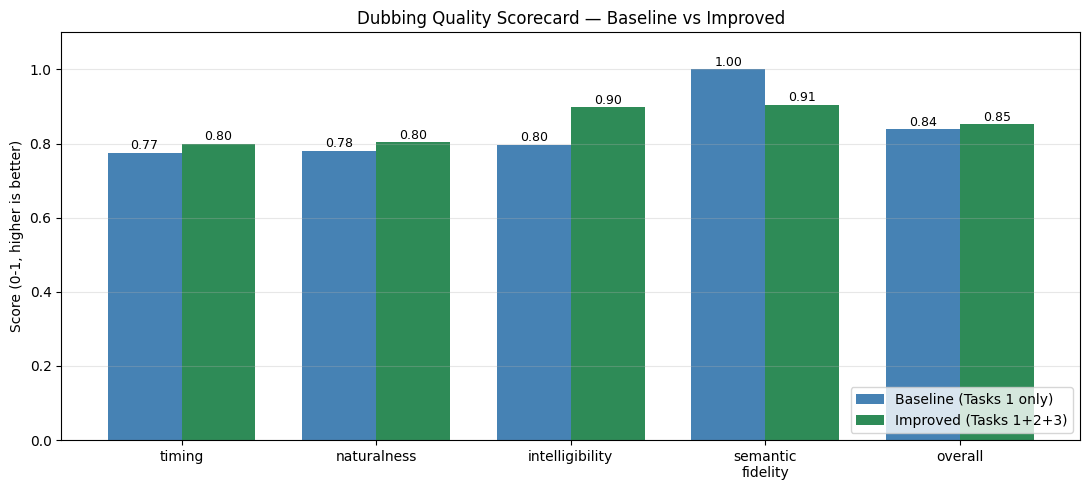

Saved to /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers/notebooks/alignment_integration/images/dubbing_scorecard.png


In [27]:
# Task 4: Visualize scorecard as a side-by-side bar chart

import matplotlib.pyplot as plt
import numpy as np

dims  = ['timing', 'naturalness', 'intelligibility', 'semantic_fidelity', 'overall']
bvals = [baseline_score[d] if baseline_score[d] is not None else 0.0 for d in dims]
ivals = [improved_score[d] if improved_score[d] is not None else 0.0 for d in dims]

x = np.arange(len(dims))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, bvals, width, label='Baseline (Tasks 1 only)', color='steelblue')
ax.bar(x + width/2, ivals, width, label='Improved (Tasks 1+2+3)', color='seagreen')

for i, v in enumerate(bvals):
    ax.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
for i, v in enumerate(ivals):
    ax.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax.set_ylabel('Score (0-1, higher is better)')
ax.set_title('Dubbing Quality Scorecard — Baseline vs Improved')
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', '\n') for d in dims])
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()

out = IMAGES_DIR / 'dubbing_scorecard.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'Saved to {out}')


---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
